In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [21]:
#energy spectrum of cooper pair box and transmon
def get_hamiltonian(Ec, Ej, N, ng):
    #charging energy
    H_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)
    #tunneling energy
    upper_diag = np.diag(np.ones(2*N), 1)
    lower_diag = np.diag(np.ones(2*N), -1)
    H_tunneling = -0.5*Ej*(upper_diag+lower_diag)
    H = H_charging + H_tunneling 
    return Qobj(H)

#plot the spectrum
def plot_spectrum(ng_val, energy_val, ymax=(20,3)):
    fig, ax = plt.subplots(figsize=(8,6))
    for n in range(len(energy_val[0,:])):
        ax.plot(ng_val, energy_val[:,n])
    ax.set_ylim(-2,ymax[0])
    ax.set_xlabel(r'$n_g$')
    ax.set_ylabel(r'$E_n$')
    return fig, ax

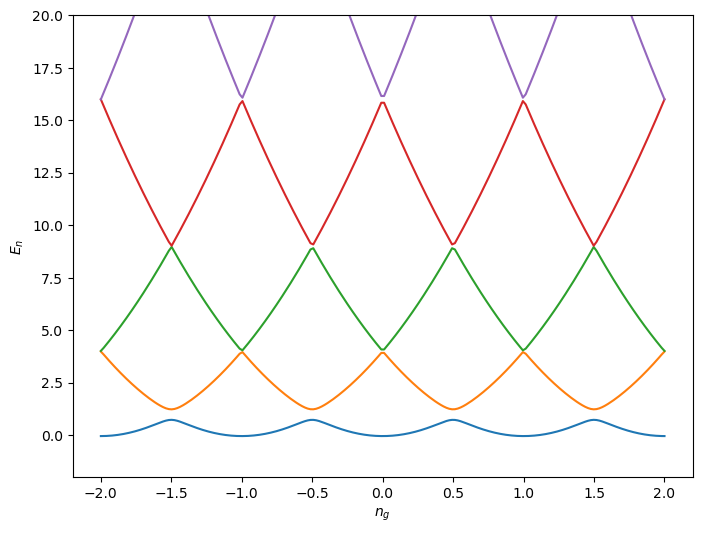

In [22]:
#charge qubit regime
N = 10
Ec = 1
Ej = 0.5

ng_val1 = np.linspace(-2,2,200)
energy_val1 = np.array([get_hamiltonian(Ec,Ej,N,ng).eigenenergies() for ng in ng_val1])

fig1, ax1 = plot_spectrum(ng_val1, energy_val1)
plt.show()

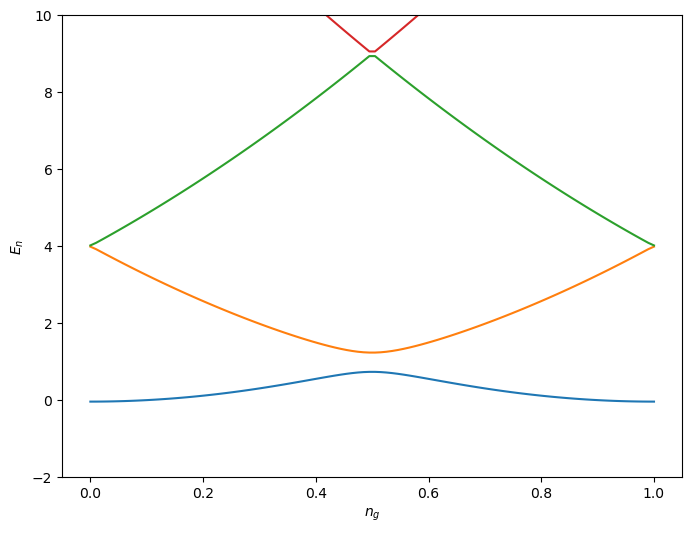

In [25]:
#charge qubit regime, ng between 0 and 1
ng_val2 = np.linspace(0,1,100)
energy_val2 = np.array([get_hamiltonian(Ec,Ej,N,ng).eigenenergies() for ng in ng_val2])

fig2, ax2 = plot_spectrum(ng_val2, energy_val2, ymax=(10,3))
plt.show()

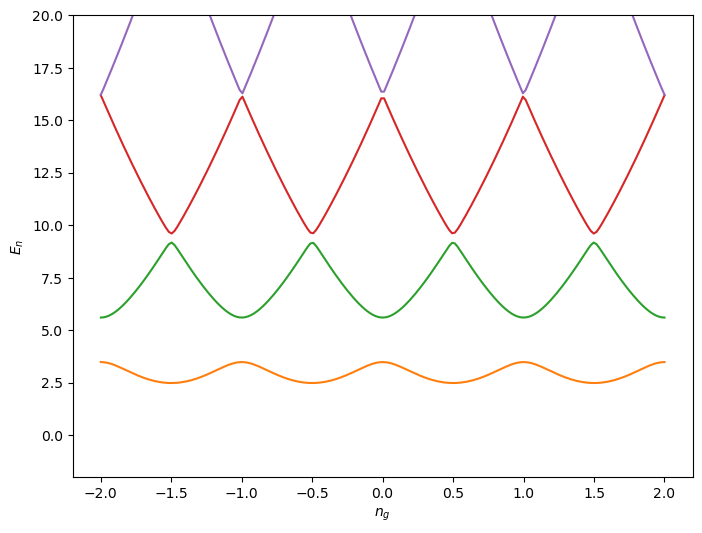

In [26]:
#intermediate regime
Ec = 1
Ej = 5

ng_val3 = np.linspace(-2,2,200)
energy_val3 = np.array([get_hamiltonian(Ec,Ej,N,ng).eigenenergies() for ng in ng_val3])

fig3, ax3 = plot_spectrum(ng_val3, energy_val3)
plt.show()

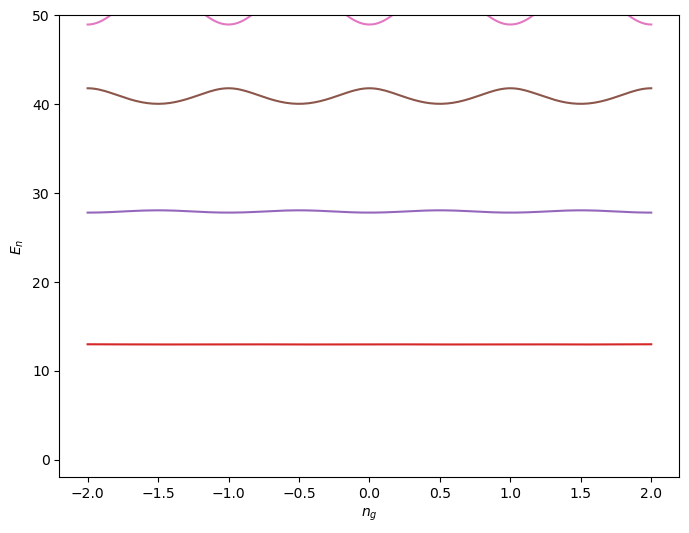

In [28]:
#transmon regime
Ec = 1
Ej = 50

ng_val3 = np.linspace(-2,2,200)
energy_val4 = np.array([get_hamiltonian(Ec,Ej,N,ng).eigenenergies() for ng in ng_val3])

fig4, ax4 = plot_spectrum(ng_val3, energy_val4, ymax=(50,3))
plt.show()

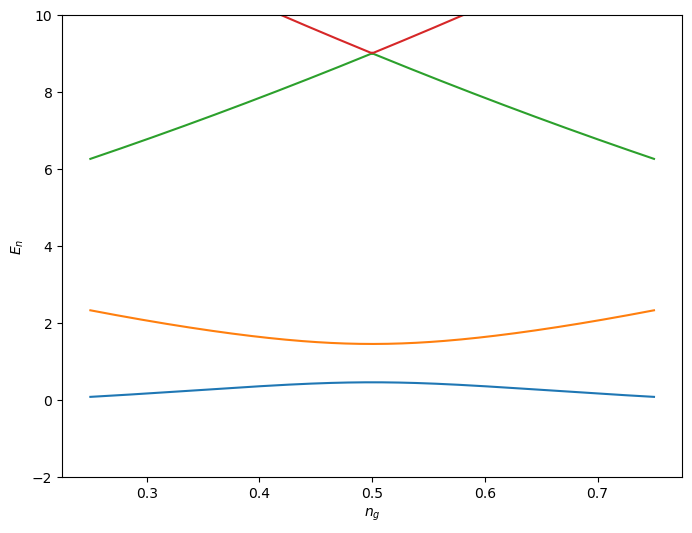

In [34]:
# charge qubit regime, two lowest levels
Ec = 1
Ej = 1

#sweet spot around ng=0.5
ng_val = np.linspace(0.25,0.75,200)
energy_val = np.array([get_hamiltonian(Ec,Ej,N,ng).eigenenergies() for ng in ng_val])

fig5, ax5 = plot_spectrum(ng_val, energy_val, ymax=(10,3))
plt.show()

In [35]:
#hamiltonian at ng=0.5
H = get_hamiltonian(Ec, Ej, N, 0.5)
H

Quantum object: dims=[[21], [21]], shape=(21, 21), type='oper', dtype=Dense, isherm=True
Qobj data =
[[441.   -0.5   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [ -0.5 361.   -0.5   0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.   -0.5 289.   -0.5   0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.   -0.5 225.   -0.5   0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.   -0.5 169.   -0.5   0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.    0.   -0.5 121.   -0.5   0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.    0.    0.   -0.5  81.   -0.5   0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    

In [36]:
eigenvalues, eigenstates = H.eigenstates()
eigenvalues

array([  0.47065435,   1.46676684,   9.01371984,   9.01760693,
        25.00520901,  25.00520943,  49.00260427,  49.00260427,
        81.00156252,  81.00156252, 121.00104167, 121.00104167,
       169.00074405, 169.00074405, 225.00055804, 225.00055804,
       289.00043403, 289.00043411, 361.00034728, 361.00347214,
       441.00312494])

In [37]:
eigenstates

array([Quantum object: dims=[[21], [1]], shape=(21, 1), type='ket', dtype=Dense
       Qobj data =
       [[4.04009909e-24]
        [3.55956441e-21]
        [2.56665082e-18]
        [1.48110460e-15]
        [6.65100328e-13]
        [2.24176365e-10]
        [5.40389960e-08]
        [8.70322580e-06]
        [8.44669667e-04]
        [4.14296852e-02]
        [7.05891541e-01]
        [7.05891541e-01]
        [4.14296852e-02]
        [8.44669667e-04]
        [8.70322580e-06]
        [5.40389960e-08]
        [2.24176365e-10]
        [6.65100328e-13]
        [1.48110460e-15]
        [2.56665082e-18]
        [3.55955881e-21]]                                                      ,
       Quantum object: dims=[[21], [1]], shape=(21, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.00000000e+00]
        [ 6.30847214e-21]
        [ 3.20051535e-18]
        [ 1.84050460e-15]
        [ 8.22824689e-13]
        [ 2.75699120e-10]
        [ 6.59095916e-08]
        [ 1.04837301e-05]
        [ 9.9

In [38]:
psi_g = eigenstates[0]  #ground state
psi_e = eigenstates[1]  #excited state

E_g = eigenvalues[0]  #ground state energy
E_e = eigenvalues[1]  #excited state energy
E_01 = E_e - E_g  #first transition energy
E_01

np.float64(0.9961124875822172)